# Dropout Regularization

Another option for neural network regularization is adding a ​dropout layer disables some neurons, while the others pass through unchanged. The idea here, similarly to regularization, is to prevent a neural network from becoming too dependent on any neuron or for any neuron to be relied upon entirely in a specific instance (which can be common if a model overfits the training data). Another problem dropout can help with is ​ co-adoption happens when neurons depend on the output values of other neurons and do not learn the underlying function on their own. Dropout can also help with ​ noise,​ which and other perturbations in the training data as more neurons working together mean that the model can learn more complex functions. 

The Dropout function works by randomly disabling neurons at a given rate during every forward pass, forcing the network to learn how to make accurate predictions with only a random part of neurons remaining.

### Dropout:
$$f(z,q) = \frac{z}{1-q} $$

$z$ is the output, $q$ is the hyperparameter setting how much impact the dropout layer has.

In [1]:
# imports
import math
import random
import numpy as np 
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import spiral_data

np.random.seed(67)

In [2]:
dropout_rate = 0.5 
# Example output containing 10 values 
example_output  =  [0.27, -1.03,  0.67,  0.99,  0.05, 
-0.37, -2.01,  1.13, -0.07,  0.73] 
# Repeat as long as necessary 
while True: 
 
    # Randomly choose index and set value to 0 
    index = random.randint(0, len(example_output) - 1) 
    example_output[index] = 0 
 
    # We might set an index that already is zeroed 
    # There are different ways of overcoming this problem, 
    # for simplicity we count values that are exactly 0 
    # while it's extremely rare in real model that weights 
    # are exactly 0, this is not the best method for sure 
    dropped_out = 0 
    for value in example_output: 
        if value == 0: 
            dropped_out += 1 
 
    # If required number of outputs is zeroed - leave the loop 
    if dropped_out / len(example_output) >= dropout_rate: 
        break 
 
print(example_output)

[0, -1.03, 0.67, 0.99, 0.05, 0, 0, 0, 0, 0.73]


# Forward Pass

In [3]:
# we can use binomial from numpy for our dropout layer
dropout_rate = 0.2

example_output = np.array([0.27, -1.03, 0.67, 0.99, 0.05, -0.37, -2.01, 1.13, -0.07, 0.73]) 

selected_dropouts = np.random.binomial(1, 1-dropout_rate, example_output.shape)

print(f"Selected dropouts {selected_dropouts}")

# multiply from our selected dropouts to disable neurons
example_output *= selected_dropouts

print(f"Output {example_output}")

Selected dropouts [1 0 1 1 1 1 1 0 1 1]
Output [ 0.27 -0.    0.67  0.99  0.05 -0.37 -2.01  0.   -0.07  0.73]


# Backwards Pass

### Deriving Dropout:
$$f(z,q) = \frac{z}{1-q} \quad \rightarrow \quad \frac{\partial}{\partial z}\left[\frac{z}{1-q}\right] = \frac{1}{1-q} \cdot \frac{\partial}{\partial z}z = \frac{1}{1-q} \cdot 1 = \frac{1}{1-q}$$

# `Layer_Dropout` Implementation

In [4]:
class Layer_Dropout:
    def __init__(self, rate):
        self.rate = rate
    
    def forward(self, inputs):
        self.inputs = inputs
        self.binary_mask = np.random.binomial(1, 1-self.rate, self.inputs.shape)
        self.output = self.inputs * self.binary_mask

    def backward(self, dvalues):
        self.dinputs = dvalues * self.binary_mask

# Initialize Current Code

In [5]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons,
                 weight_regularizer_l1=0, bias_regularizer_l1=0,
                 weight_regularizer_l2=0, bias_regularizer_l2=0):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

        self.weight_regularizer_l1 = weight_regularizer_l1
        self.bias_regularizer_l1 = bias_regularizer_l1
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l2 = bias_regularizer_l2        

    def forward(self, inputs):
        self.inputs = inputs 
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues) 
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)         

        if self.weight_regularizer_l1 > 0:
            dL1 = np.ones_like(self.weights)
            dL1[self.weights < 0] = -1
            self.dweights += self.weight_regularizer_l1 * dL1
        if self.bias_regularizer_l1 > 0:
            dL1 = np.ones_like(self.biases)
            dL1[self.biases < 0] = -1
            self.dbiases += self.bias_regularizer_l1 * dL1

        if self.weight_regularizer_l2 > 0:
            self.dweights += 2 * self.weight_regularizer_l2 * self.weights
        if self.bias_regularizer_l2 > 0:
            self.dbiases += 2 * self.bias_regularizer_l2 * self.biases

        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU: 
    def forward(self, inputs): 
        self.inputs = inputs 
        self.output = np.maximum(0, inputs) 

    def backward(self, dvalues): 
        self.dinputs = dvalues.copy() 
        self.dinputs[self.inputs <= 0] = 0 

class Loss: 
    def regularization_loss(self, layer):
        regularization_loss = 0

        if layer.weight_regularizer_l1 > 0:
            regularization_loss += layer.weight_regularizer_l1 * np.sum(np.abs(layer.weights))
        if layer.bias_regularizer_l1 > 0:
            regularization_loss += layer.bias_regularizer_l1 * np.sum(np.abs(layer.biases))

        if layer.weight_regularizer_l2 > 0:
            regularization_loss += layer.weight_regularizer_l2 * np.sum(layer.weights ** 2)
        if layer.bias_regularizer_l2 > 0:
            regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.biases ** 2)
        
        return regularization_loss

    def calculate(self, output, y): 
        sample_losses = self.forward(output, y) 
        data_loss = np.mean(sample_losses) 
        return data_loss 
 
class Loss_CategoricalCrossentropy(Loss): 
    def forward(self, y_pred, y_true): 
        samples = len(y_pred) 
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7) 
        if len(y_true.shape) == 1: 
            correct_confidences = y_pred_clipped[range(samples), y_true] 
        elif len(y_true.shape) == 2: 
            correct_confidences = np.sum(y_pred_clipped * y_true, axis=1) 
 
        negative_log_likelihoods = -np.log(correct_confidences) 
        return negative_log_likelihoods 
 
    def backward(self, dvalues, y_true): 
        samples = len(dvalues) 
        labels = len(dvalues[0]) 

        if len(y_true.shape) == 1: 
            y_true = np.eye(labels)[y_true] 
 
        self.dinputs = -y_true / dvalues 
        self.dinputs = self.dinputs / samples 
    
class Activation_Softmax: 
    def forward(self, inputs): 
        self.inputs = inputs 
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities 

    def backward(self, dvalues): 
        self.dinputs = np.empty_like(dvalues) 
 
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)): 
            single_output = single_output.reshape(-1, 1) 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T) 

            self.dinputs[index] = np.dot(jacobian_matrix, 
                                         single_dvalues) 
 
class Activation_Softmax_Loss_CategoricalCrossentropy(): 
    def __init__(self): 
        self.activation = Activation_Softmax() 
        self.loss = Loss_CategoricalCrossentropy() 
 
    def forward(self, inputs, y_true): 
        self.activation.forward(inputs) 
        self.output = self.activation.output 
        return self.loss.calculate(self.output, y_true) 
 
    def backward(self, dvalues, y_true): 
 
        samples = len(dvalues) 
 
        if len(y_true.shape) == 2: 
            y_true = np.argmax(y_true, axis=1) 
 
        self.dinputs = dvalues.copy() 
        self.dinputs[range(samples), y_true] -= 1 
        self.dinputs = self.dinputs / samples 

class Optimizer_Adam: 
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999): 
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate 
        self.decay = decay 
        self.iterations = 0 
        self.epsilon = epsilon 
        self.beta_1 = beta_1 
        self.beta_2 = beta_2 
 
    def pre_update_params(self): 
        if self.decay: 
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations)) 
 
    def update_params(self, layer): 
 
        if not hasattr(layer, 'weight_cache'): 
            layer.weight_momentums = np.zeros_like(layer.weights) 
            layer.weight_cache = np.zeros_like(layer.weights) 
            layer.bias_momentums = np.zeros_like(layer.biases) 
            layer.bias_cache = np.zeros_like(layer.biases) 
 
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights 
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases 

        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 

        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2 
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2 

        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
 
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon) 
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon) 
 
    def post_update_params(self): 
        self.iterations += 1 

    

# Run Model

In [6]:
X, y = spiral_data(samples=100, classes=3) 

learning_rate = 0.05
decay = 5e-5
dropout_rate = 0.1
n_neurons = 512
dense1 = Layer_Dense(2, n_neurons, weight_regularizer_l2=5e-4, 
                            bias_regularizer_l2=5e-4) 
activation1 = Activation_ReLU() 

dropout1 = Layer_Dropout(dropout_rate)

dense2 = Layer_Dense(n_neurons, 3) 
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy() 
optimizer = Optimizer_Adam(learning_rate=learning_rate, decay=decay) 

loss_history, accuracy_history, learning_rate_history = [], [], []

for epoch in range(10001): 
    # Forward pass
    dense1.forward(X) 
    activation1.forward(dense1.output) 

    # pass dropout to dense2 from activation output
    dropout1.forward(activation1.output)
    dense2.forward(dropout1.output) 

    # Regularization
    data_loss = loss_activation.forward(dense2.output, y) 
    regularization_loss = loss_activation.loss.regularization_loss(dense1) + loss_activation.loss.regularization_loss(dense2) 
    loss = data_loss + regularization_loss 

    predictions = np.argmax(loss_activation.output, axis=1) 
    if len(y.shape) == 2: 
        y = np.argmax(y, axis=1) 
    accuracy = np.mean(predictions==y) 
 
    if not epoch % 1000: 
        print(f'epoch: {epoch}, ' + 
              f'acc: {accuracy:.3f}, ' + 
              f'loss: {loss:.3f} (' + 
              f'data_loss: {data_loss:.3f}, ' + 
              f'reg_loss: {regularization_loss:.3f}), ' + 
              f'lr: {optimizer.current_learning_rate}') 
 
    # Backward pass 
    loss_activation.backward(loss_activation.output, y) 
    dense2.backward(loss_activation.dinputs) 

    # backwards pass, loss activation dinputs to dropout
    dropout1.backward(dense2.dinputs)
    activation1.backward(dropout1.dinputs) 
    dense1.backward(activation1.dinputs) 
 
    optimizer.pre_update_params() 
    optimizer.update_params(dense1) 
    optimizer.update_params(dense2) 
    optimizer.post_update_params() 
    
    loss_history.append(loss)
    accuracy_history.append(accuracy)
    learning_rate_history.append(optimizer.current_learning_rate)

epoch: 0, acc: 0.307, loss: 1.112 (data_loss: 1.107, reg_loss: 0.005), lr: 0.05
epoch: 1000, acc: 0.850, loss: 0.499 (data_loss: 0.384, reg_loss: 0.115), lr: 0.04762131530072861
epoch: 2000, acc: 0.837, loss: 0.528 (data_loss: 0.418, reg_loss: 0.110), lr: 0.045456611664166556
epoch: 3000, acc: 0.840, loss: 0.517 (data_loss: 0.413, reg_loss: 0.104), lr: 0.043480151310926564
epoch: 4000, acc: 0.823, loss: 0.533 (data_loss: 0.431, reg_loss: 0.102), lr: 0.04166840285011875
epoch: 5000, acc: 0.860, loss: 0.465 (data_loss: 0.368, reg_loss: 0.097), lr: 0.04000160006400256
epoch: 6000, acc: 0.860, loss: 0.465 (data_loss: 0.365, reg_loss: 0.100), lr: 0.03846301780837725
epoch: 7000, acc: 0.843, loss: 0.551 (data_loss: 0.456, reg_loss: 0.095), lr: 0.03703840882995667
epoch: 8000, acc: 0.877, loss: 0.439 (data_loss: 0.340, reg_loss: 0.099), lr: 0.03571556127004536
epoch: 9000, acc: 0.870, loss: 0.452 (data_loss: 0.355, reg_loss: 0.097), lr: 0.034483947722335255
epoch: 10000, acc: 0.860, loss: 0.4

# Validate with Test Dataset

In [7]:
# test dataset
X_test, y_test = spiral_data(samples=200,  classes=3) 

dense1.forward(X_test) 
activation1.forward(dense1.output) 
dense2.forward(activation1.output) 
loss = loss_activation.forward(dense2.output, y_test) 
predictions  =  np.argmax(loss_activation.output,  axis=1) 

if len(y_test.shape)  ==  2: 
    y_test  =  np.argmax(y_test,  axis=1) 
accuracy = np.mean(predictions==y_test) 
print(f'validation, acc:  {accuracy:.3f}, loss:  {loss:.3f}')

validation, acc:  0.818, loss:  0.595


# Initialize Plot Decision Boundary

In [8]:
def plot_decision_boundary(model_layers, X, y, resolution=0.02, title="Neural Network Decision Boundaries"):
    from scipy.ndimage import gaussian_filter
    import matplotlib.pyplot as plt
    import numpy as np

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, resolution),
        np.arange(y_min, y_max, resolution)
    )

    Z_input = np.c_[xx.ravel(), yy.ravel()]

    # Forward pass
    dense1.forward(Z_input)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss_activation.forward(dense2.output, np.zeros((len(Z_input), 3)))

    probs = loss_activation.output  # shape: (N, 3)

    class_colors = np.array([
        [0.85, 0.35, 0.35],   
        [0.35, 0.75, 0.40],   
        [0.40, 0.45, 0.85],   
    ])  # shape: (3, 3)

    rgb_map = probs @ class_colors  # weighted mix of class colors
    rgb_map = np.clip(rgb_map, 0, 1)

    # Smooth each channel with gaussian blur to soften hard edges
    H, W = xx.shape
    rgb_image = rgb_map.reshape(H, W, 3)
    for c in range(3):
        rgb_image[:, :, c] = gaussian_filter(rgb_image[:, :, c], sigma=2.0)
    rgb_image = np.clip(rgb_image, 0, 1)

    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw blended background
    ax.imshow(
        rgb_image,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        aspect='auto',
        alpha=0.85
    )

    # Scatter: color each point by its true class using same class colors
    y_labels = y if len(y.shape) == 1 else np.argmax(y, axis=1)
    point_colors = class_colors[y_labels]

    ax.scatter(
        X[:, 0], X[:, 1],
        c=point_colors,
        edgecolors='k',
        linewidths=0.4,
        s=50,
        alpha=0.9
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Visualize Data

Final Values: Loss 0.4297392850997478 Accuracy 0.86 Learning Rate 0.03333333333333333
Learning Rate 0.05 Decay 5e-05


C:\Users\paolo\AppData\Local\Temp\ipykernel_2300\2902449928.py:76: RuntimeWarning: divide by zero encountered in log
  negative_log_likelihoods = -np.log(correct_confidences)


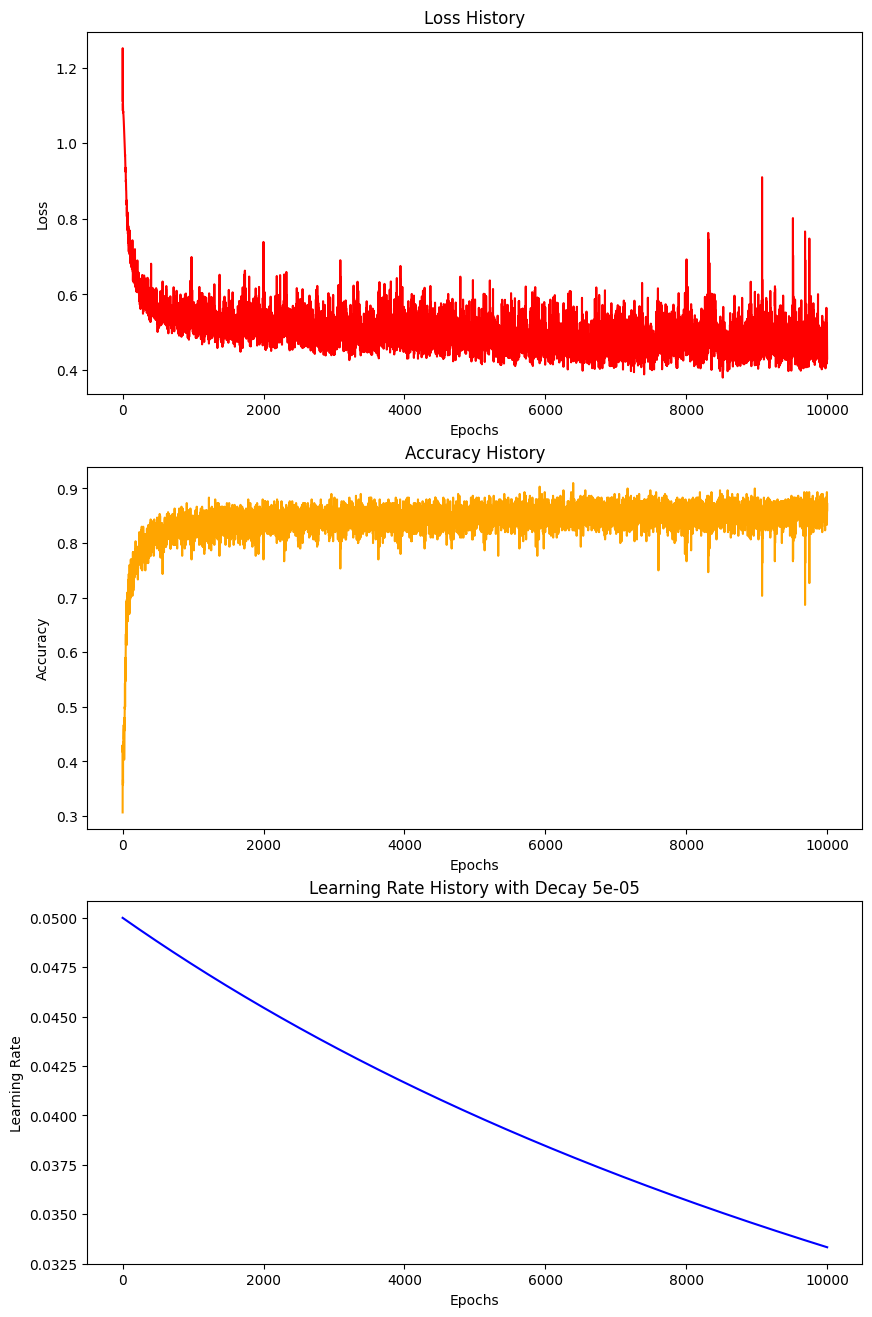

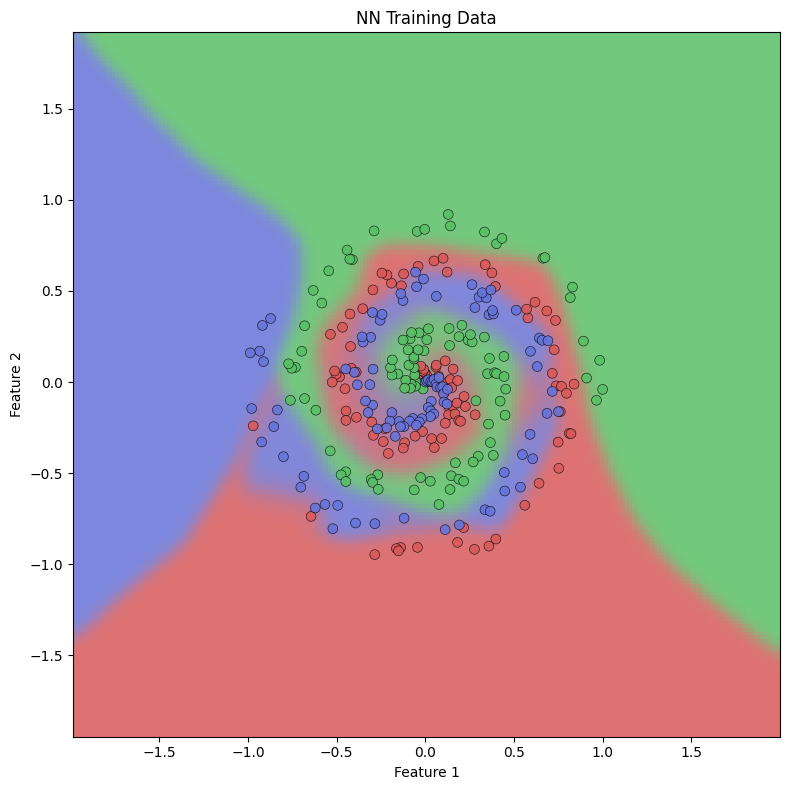

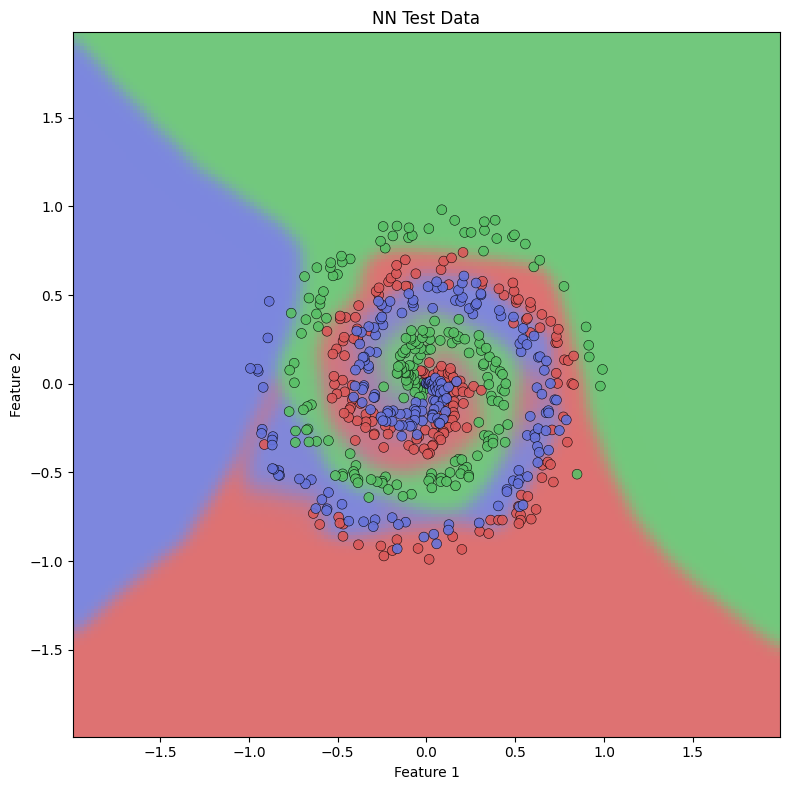

In [9]:
fig, axes = plt.subplots(nrows=3, figsize=(10, 16))

axes[0].set_title("Loss History")
axes[0].plot(loss_history, color="red")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")

axes[1].set_title("Accuracy History")
axes[1].plot(accuracy_history, color="orange")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")

axes[2].set_title(f"Learning Rate History with Decay {decay}")
axes[2].plot(learning_rate_history, color="blue")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Learning Rate")

print(f"Final Values: Loss {loss_history[-1]} Accuracy {accuracy_history[-1]} Learning Rate {learning_rate_history[-1]}")
print(f"Learning Rate {learning_rate} Decay {decay}")
plot_decision_boundary([dense1, activation1, dense2, loss_activation], X, y, title="NN Training Data")
plot_decision_boundary([dense1, activation1, dense2, loss_activation], X_test, y_test, title="NN Test Data")

